<a href="https://colab.research.google.com/github/InsightMart/DSPL_project/blob/main/LR_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preperation

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import learning_curve

In [ ]:
# Load Dataset using pandas library
import pandas as pd
df=pd.read_csv('/content/cleaned_traincsv.csv')

# Display first few rows
df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4


In [ ]:
# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical column (Ensure it's a DataFrame)
encode = ohe.fit_transform(df[['outlet_city']])
# Create a dataframe
df_encoded = pd.DataFrame(encode, columns=ohe.get_feature_names_out(['outlet_city']))
df = df.join(df_encoded)

# Display first few rows
df.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_Batticaloa,outlet_city_Colombo,outlet_city_Dehiwala-Mount Lavinia,outlet_city_Galle,...,outlet_city_Katunayake,outlet_city_Kelaniya,outlet_city_Kotte,outlet_city_Moratuwa,outlet_city_Negombo,outlet_city_Nuwara Eliya,outlet_city_Panadura,outlet_city_Peliyagoda,outlet_city_Trincomalee,outlet_city_Wattala
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Scaling

numerical_columns = df[['luxury_sales', 'fresh_sales', 'dry_sales']]

# Standardize input variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1 = scaler.fit_transform(numerical_columns)

In [ ]:
# Create a dataframe for Featuers (X) and Targets (y)
X = pd.concat([pd.DataFrame(X1, columns=['luxury_sales', 'fresh_sales', 'dry_sales']), df_encoded], axis=1)
y = df['cluster_catgeory']

<Axes: >

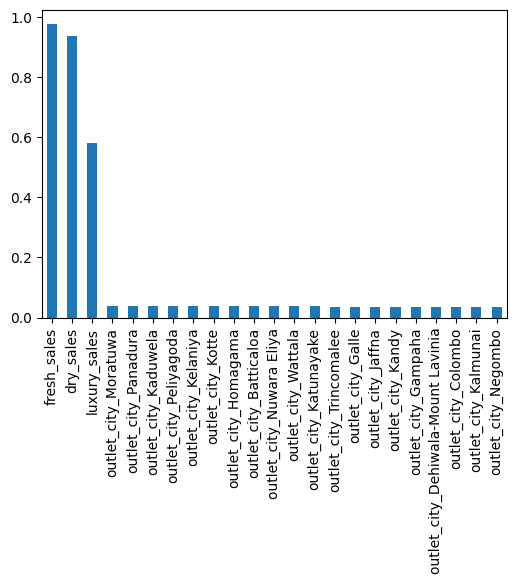

In [ ]:
# Feature importance

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

fs = SelectKBest(score_func=mutual_info_classif, k=10)
fs.fit(X, y)
mi_score = pd.Series(fs.scores_, index=X.columns)
mi_score.sort_values(ascending=False).plot.bar(figsize=(6, 4))

In [ ]:
from sklearn.model_selection import train_test_split

# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Whole Data shape', df.shape)
print('X1_train shape', X_train.shape)
print('X1_test shape', X_test.shape)

Whole Data shape (774150, 26)
X1_train shape (541905, 23)
X1_test shape (232245, 23)


## 1. Logistic Regression Model

In [ ]:
# Import the function from the package
from sklearn.linear_model import LogisticRegression

# instantiate the model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

#Perform predictions on the test data
y_pred1=logreg.predict(X_test)

In [ ]:
# Create a dataframe for comparing the actual vs predicted results by logistic regression classifier model
Comparison_df = pd.DataFrame({'Actual cluster_catgeory' : y_test, 'Predicted cluster_catgeory' : y_pred1})
Comparison_df

,Actual cluster_catgeory,Predicted cluster_catgeory
201122,2,2
207061,2,2
375630,1,1
552084,1,1
24499,4,4
...,...,...
253842,2,2
615954,6,6
338522,5,5
710046,6,6


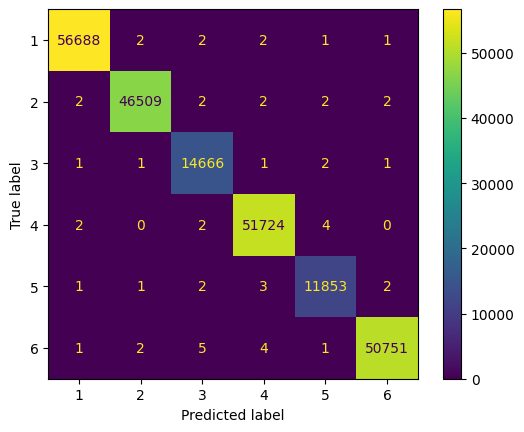

In [ ]:
# Import the function from the package
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Construct the confusion matrix cm
cm = confusion_matrix(y_test, y_pred1, labels=logreg.classes_)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=logreg.classes_)
disp.plot()

In [ ]:
# Classification metrics report

# Import the function from the package
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     56696
           2       1.00      1.00      1.00     46519
           3       1.00      1.00      1.00     14672
           4       1.00      1.00      1.00     51732
           5       1.00      1.00      1.00     11862
           6       1.00      1.00      1.00     50764

    accuracy                           1.00    232245
   macro avg       1.00      1.00      1.00    232245
weighted avg       1.00      1.00      1.00    232245



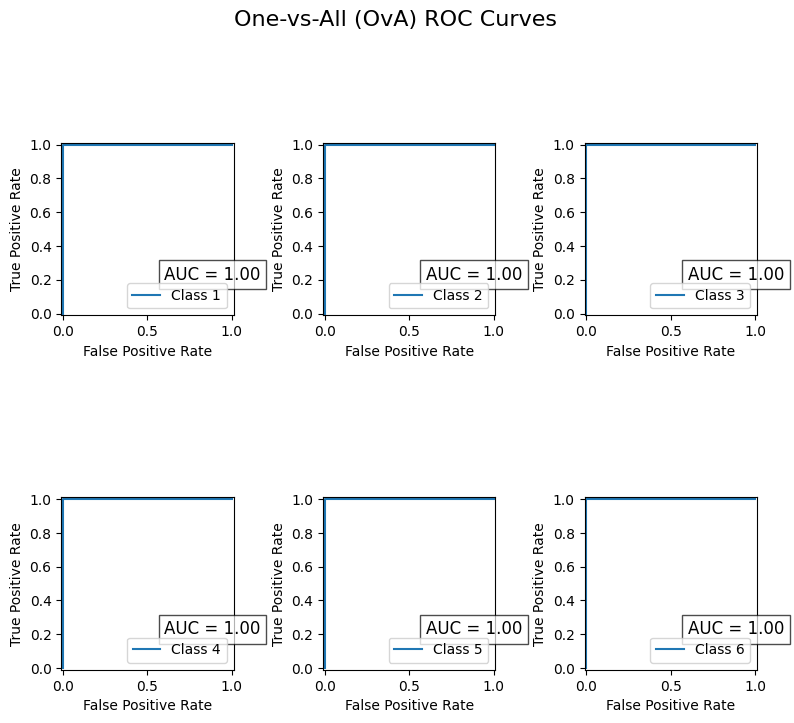

In [ ]:
# ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob1 = logreg.predict_proba(X_test)

# Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(logreg.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob1[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob1[:, i])  # Calculate AUC
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))  # Add AUC value to the plot

plt.suptitle("One-vs-All (OvA) ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust the top to fit the suptitle
plt.show()

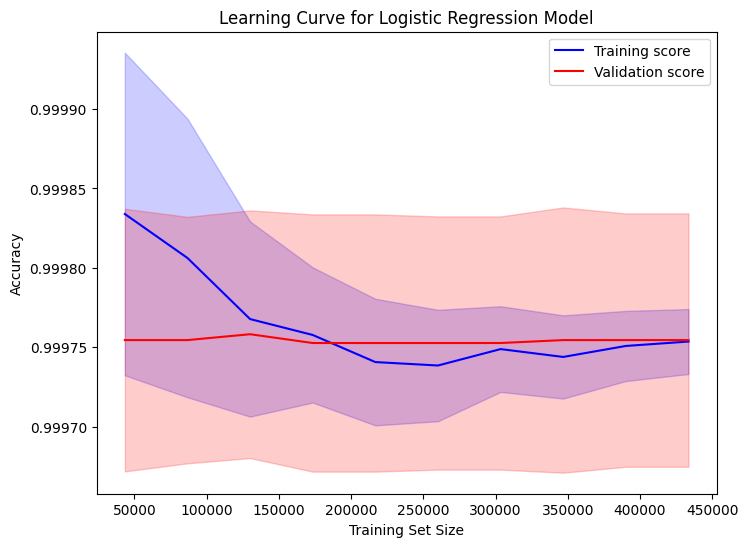

In [ ]:
# Learning Curve

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(logreg, X_train, y_train,
                                                         train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                         cv=5, scoring='accuracy', n_jobs=-1)

# Calculate the mean and standard deviation of the training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.plot(train_sizes, valid_mean, label='Validation score', color='r')

# Plot the fill between the standard deviations for training and validation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='b', alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color='r', alpha=0.2)

# Label the plot
plt.title('Learning Curve for Logistic Regression Model')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.show()

## 2. Tuned Logistic Regression Model

In [ ]:
# Import the function from the package
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np

# create new a log_reg model
log_reg = LogisticRegression(max_iter=500)

# Define hyperparameter grid
param_grid1 = {'C': np.logspace(-3, 3, 5), # Regularization strength
                 'penalty': ['l1', 'l2'], # Regularization type
                 'solver': ['liblinear'] } # Suitable solver for L1 and L2

#use gridsearch to test all values
lr_gscv = GridSearchCV(log_reg, param_grid1, cv=3, scoring='roc_auc_ovr')
#fit model to data
lr_gscv.fit(X_train, y_train)

# Get the best estimator (tuned model)
best_lr = lr_gscv.best_estimator_
best_lr

LogisticRegression(C=np.float64(0.03162277660168379), max_iter=500,
                   solver='liblinear')

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     56696
           2       1.00      1.00      1.00     46519
           3       1.00      1.00      1.00     14672
           4       1.00      1.00      1.00     51732
           5       1.00      1.00      1.00     11862
           6       1.00      1.00      1.00     50764

    accuracy                           1.00    232245
   macro avg       1.00      1.00      1.00    232245
weighted avg       1.00      1.00      1.00    232245



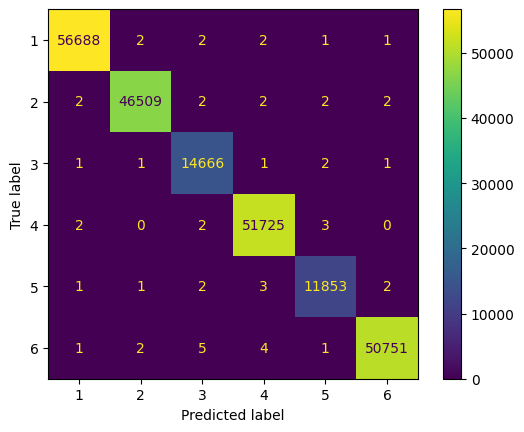

In [ ]:
# Perform testing on test dataset
y_pred2 = best_lr.predict(X_test)

# Construct a confusion matrix
cm_best_lr = confusion_matrix(y_test, y_pred2, labels = best_lr.classes_)
disp_best_lr_cm = ConfusionMatrixDisplay(cm_best_lr, display_labels=best_lr.classes_)
disp_best_lr_cm.plot()

# Display the classification report
print(classification_report(y_test, y_pred2))

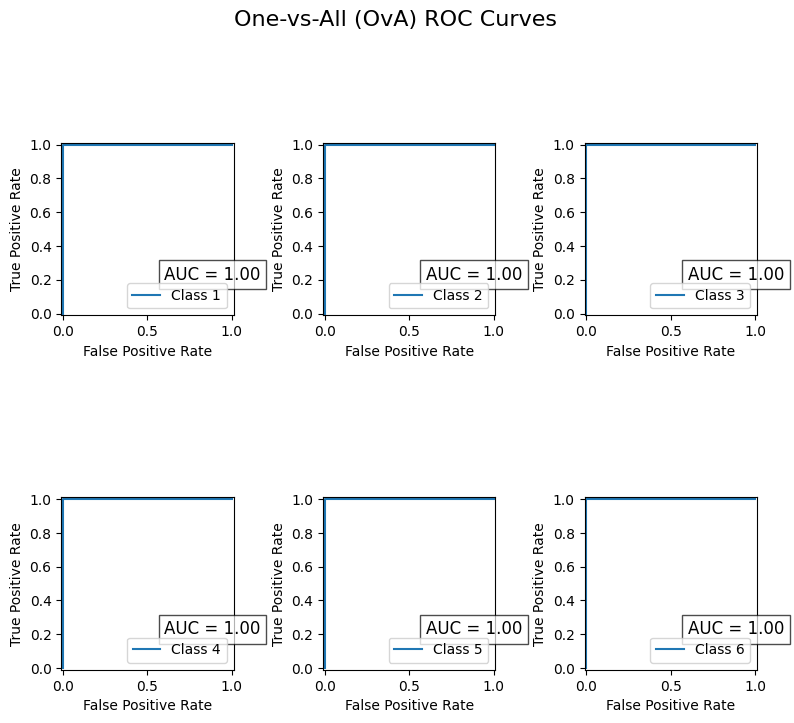

In [ ]:
# ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob2 = best_lr.predict_proba(X_test)

# Create a 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(best_lr.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob2[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob2[:, i])  # Calculate AUC
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))  # Add AUC value to the plot

plt.suptitle("One-vs-All (OvA) ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust the top to fit the suptitle
plt.show()

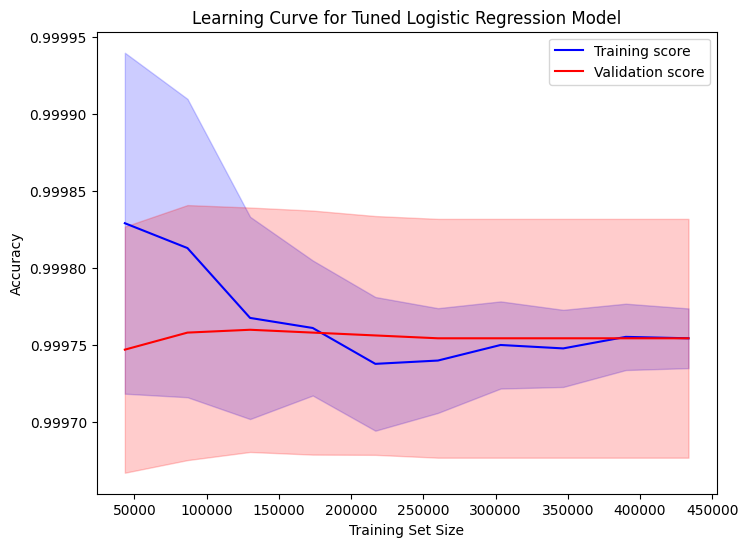

In [ ]:
# Learning Curve

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(best_lr, X_train, y_train,
                                                         train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                         cv=5, scoring='accuracy', n_jobs=-1)

# Calculate the mean and standard deviation of the training and validation scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training score', color='b')
plt.plot(train_sizes, valid_mean, label='Validation score', color='r')

# Plot the fill between the standard deviations for training and validation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='b', alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, color='r', alpha=0.2)

# Label the plot
plt.title('Learning Curve for Tuned Logistic Regression Model')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.show()

## saving

In [ ]:
import joblib
from google.colab import files

# Define models and preprocessing objects with filenames
objects_to_save = {"outlet_city_encoder": ohe, "scaler": scaler, 'logreg': logreg, 'best_lr': best_lr}

# Save each object to a joblib file
for name, obj in objects_to_save.items():
    joblib.dump(obj, f"{name}.joblib")

# List of files to download
files_to_download = [f"{name}.joblib" for name in objects_to_save.keys()]

# Download each file
for file in files_to_download:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>